### Nossos objetivos e entendimentos comuns sobre o modelo: XGBoost

O XGBoost é um algoritmo de ensemble baseado em boosting, ele combina múltiplas árvores de decisão de forma sequencial, onde cada árvore corrige os erros da anterior. Diferente do Random Forest que treina árvores em paralelo via bagging, o XGBoost treina iterativamente minimizando uma função de perda com gradiente descendente. É o terceiro modelo do projeto, escolhido por ser estado da arte em dados tabulares, altamente customizável via hiperparâmetros e por também gerar importância das features, mantendo a interpretabilidade clínica.

### Bibliotecas e imports

In [2]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from utils_fc_notes import avaliar_modelo, plt_matriz_confusao
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

### Carregamento de dados

Carregamos os quatro arquivos gerados pelo pré-processamento. O treino está balanceado e normalizado. Já o teste está com a distribuição real e desbalanceada para simular a entrada de dados no modelo.

In [13]:
X_train = pd.read_csv('../data/processed_data/X_train.csv')
X_test  = pd.read_csv('../data/processed_data/X_test.csv')
y_train = pd.read_csv('../data/processed_data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed_data/y_test.csv').squeeze()

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
print()
print('Distribuição y_test (dados reais):')
print(y_test.value_counts())
print('  0 = Alive | 1 = Dead')

X_train: (5450, 14) | y_train: (5450,)
X_test:  (805, 14)  | y_test:  (805,)

Distribuição y_test (dados reais):
Status
0    682
1    123
Name: count, dtype: int64
  0 = Alive | 1 = Dead


### Treinamento do modelo
O XGBoost é instanciado com 100 árvores e random_state=42 para reprodutibilidade. O n_jobs=-1 usa todos os núcleos disponíveis. O eval_metric='logloss' evita warnings de versões recentes da biblioteca. Diferente do Random Forest, o XGBoost treina as árvores sequencialmente — cada nova árvore foca nos erros que a anterior cometeu, o que tende a gerar modelos mais precisos em dados tabulares.

In [4]:
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print(f'Número de árvores: {xgb.n_estimators}')
print(f'Features utilizadas: {xgb.n_features_in_}')

Número de árvores: 100
Features utilizadas: 14


### Métricas
Avaliamos o modelo com Acurácia, Precisão, Recall, F1-Score e AUC-ROC, as mesmas métricas do baseline e do Random Forest para comparação direta. O classification_report detalha as métricas separadamente para cada classe dos dados (Alive e Dead).

In [5]:
avaliar_modelo(y_test, y_pred)

,Valor
Acurácia,0.822360
Precisão,0.371795
Recall,0.235772
F1-score,0.288557
AUC-ROC,0.581962


In [6]:
print(classification_report(y_test, y_pred, target_names=['Alive (0)', 'Dead (1)'], zero_division=0))

              precision    recall  f1-score   support

   Alive (0)       0.87      0.93      0.90       682
    Dead (1)       0.37      0.24      0.29       123

    accuracy                           0.82       805
   macro avg       0.62      0.58      0.59       805
weighted avg       0.79      0.82      0.81       805



### Matriz de confusão
Visualiza a distribuição das previsões, especialmente os Falsos Negativos (Dead previsto como Alive), que representam o pior cenário clínico, que seria um paciente em risco não identificado pelo modelo.

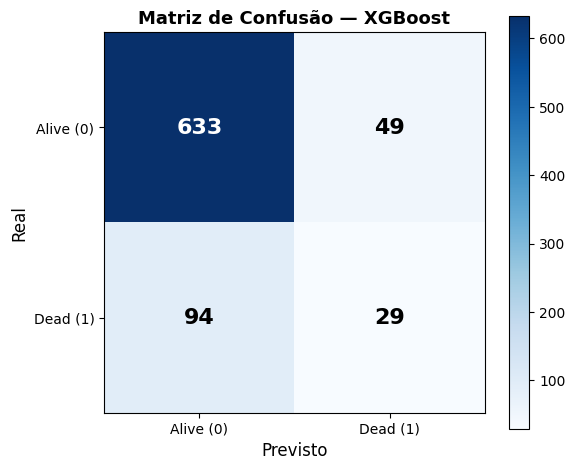


Verdadeiros Negativos: 633
Falsos Positivos: 49
Falsos Negativos: 94
Verdadeiros Positivos: 29


In [7]:
plt_matriz_confusao(
    y_test,
    y_pred,
    nome_modelo='XGBoost',
    salvar=True,
    caminho='../assets/charts_images/distributions/cm_xgboost.png'
)

### Features Importantes

O XGBoost calcula a importância de cada feature com base no ganho médio que ela proporciona nas divisões das árvores (métrica 'gain'). As mais importantes foram Reginol_Node_Positive, Progesterone_Status e 6th_Stage, alinhado com os insights da EDA e consistente com o que o Random Forest também identificou, o que reforça a relevância dessas variáveis no contexto clínico.

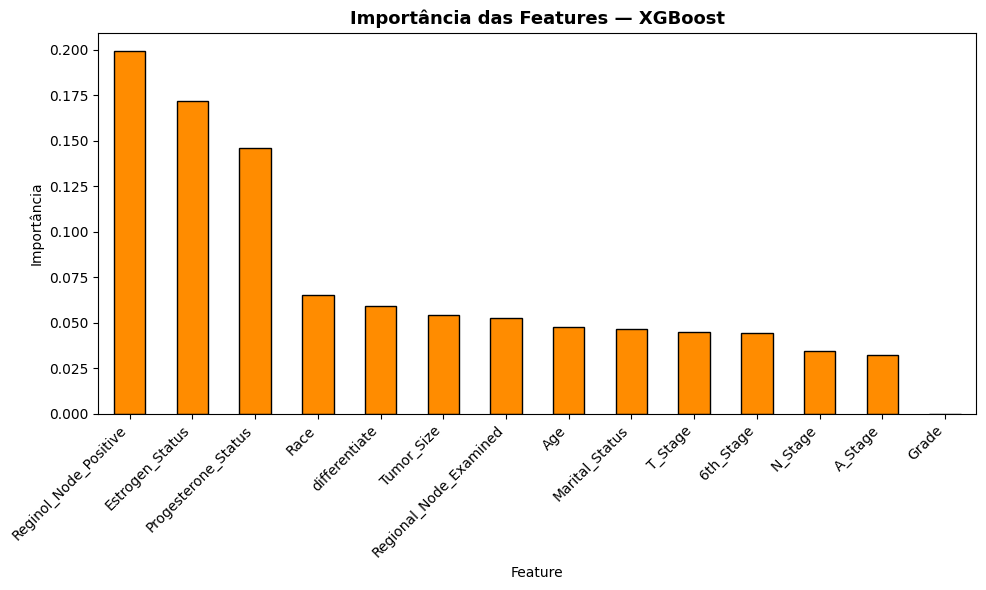


Importância por feature:
Reginol_Node_Positive     0.1993
Estrogen_Status           0.1717
Progesterone_Status       0.1458
Race                      0.0651
differentiate             0.0595
Tumor_Size                0.0545
Regional_Node_Examined    0.0526
Age                       0.0480
Marital_Status            0.0465
T_Stage                   0.0450
6th_Stage                 0.0447
N_Stage                   0.0348
A_Stage                   0.0325
Grade                     0.0000


In [8]:
fi = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
fi.plot(kind='bar', ax=ax, color='darkorange', edgecolor='black')
ax.set_title('Importância das Features — XGBoost', fontsize=13, fontweight='bold')
ax.set_ylabel('Importância')
ax.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../assets/charts_images/distributions/feature_importance_xgboost.png', dpi=150)
plt.show()

print('\nImportância por feature:')
print(fi.round(4).to_string())

### Hiperparâmetros

Utilizamos GridSearchCV para buscar a melhor combinação de hiperparâmetros. O grid do XGBoost inclui parâmetros exclusivos do algoritmo: learning_rate (taxa de aprendizado — quanto cada árvore contribui), subsample (fração de amostras por árvore) e colsample_bytree (fração de features por árvore). O grid gerou 32 combinações × 5 folds = 160 treinamentos. O scoring='recall' prioriza a detecção de Dead. Os melhores parâmetros encontrados foram: max_depth=7, learning_rate=0.1, n_estimators=100, subsample=1.0 e colsample_bytree=0.8.

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='recall', 
    n_jobs=-1
)

grid.fit(X_train, y_train)

print('Melhores parâmetros:', grid.best_params_)
print('Melhor Recall (CV):', grid.best_score_.round(4))

xgb_best = grid.best_estimator_
y_pred = xgb_best.predict(X_test)

Melhores parâmetros: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Melhor Recall (CV): 0.8367


In [10]:
y_pred = grid.best_estimator_.predict(X_test)
avaliar_modelo(y_test, y_pred)

,Valor
Acurácia,0.822360
Precisão,0.386364
Recall,0.276423
F1-score,0.322275
AUC-ROC,0.598622


### Salvamento do modelo

O melhor modelo encontrado pelo GridSearch é serializado com joblib em models/xgboost.joblib. Esse arquivo será carregado pelo backend FastAPI para fazer previsões em produção sem precisar retreinar.

In [11]:
os.makedirs('../models', exist_ok=True)

joblib.dump(xgb_best, '../models/xgboost.joblib')

['../models/xgboost.joblib']